## Task 3 : Exploratory Data Analysis & Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("clean_cricket_dataset.csv")
df.head()

,Player,Span,Matches,Runs,Highest_score,Batting_Avg,Centuries,Wickets,Bowl Av,Five_Wicket_Hauls,Catches,Stumpings,Ave Diff,performance_score
0,SR Tendulkar,1989-2013,664,34357,248,48.52,100,201,46.53,2,256,0,1.98,1.99
1,DPMD Jayawardene,1997-2015,652,25957,374,39.15,54,14,62.92,0,440,0,23.77,-23.77
2,KC Sangakkara,2000-2015,594,28016,319,46.77,63,0,0.00,0,609,139,0.00,46.77
3,ST Jayasuriya,1989-2011,586,21032,340,34.14,42,440,35.66,6,205,0,1.52,-1.52
4,RT Ponting,1995-2012,560,27483,257,45.95,71,8,47.50,0,364,0,1.54,-1.55


In [3]:
df.describe()

,Matches,Runs,Highest_score,Batting_Avg,Centuries,Wickets,Bowl Av,Five_Wicket_Hauls,Catches,Stumpings,Ave Diff,performance_score
count,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000
mean,36.783485,800.415455,53.953485,16.367312,1.051515,27.576515,23.133670,0.618485,17.050606,0.733788,13.700336,-6.766358
std,65.453988,2246.041539,55.497377,11.934692,4.673982,76.587624,25.830291,2.713454,44.273970,5.302964,21.301094,28.778627
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-332.770000
25%,5.000000,31.000000,14.000000,7.330000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-20.620000
50%,13.000000,132.000000,37.000000,14.460000,0.000000,4.000000,21.245000,0.000000,4.000000,0.000000,6.355000,-5.470000
75%,35.000000,512.000000,73.000000,23.250000,0.000000,20.000000,34.000000,0.000000,14.000000,0.000000,19.847500,12.750000
max,664.000000,34357.000000,400.000000,117.000000,100.000000,1347.000000,359.000000,77.000000,953.000000,195.000000,332.760000,117.000000


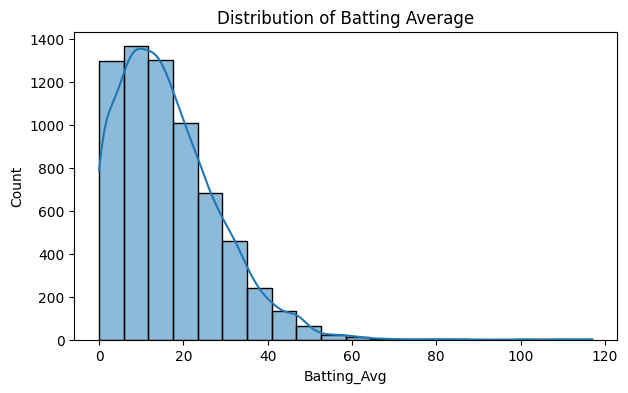

In [7]:
plt.figure(figsize=(7,4))
sns.histplot(df["Batting_Avg"], bins=20, kde=True)
plt.title("Distribution of Batting Average")
plt.show()

The majority of players fall between 5 and 25 batting average.Only a small number of elite all-rounders maintain very high batting averages.

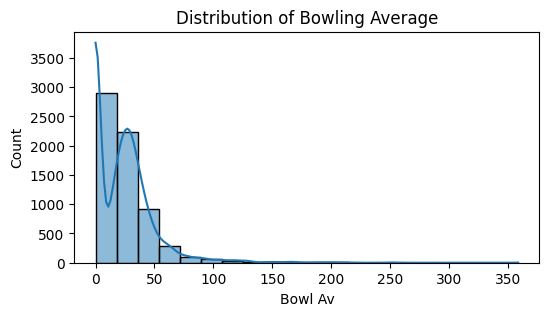

In [11]:
plt.figure(figsize=(6,3))
sns.histplot(df["Bowl Av"], bins=20, kde=True)
plt.title("Distribution of Bowling Average")
plt.show()

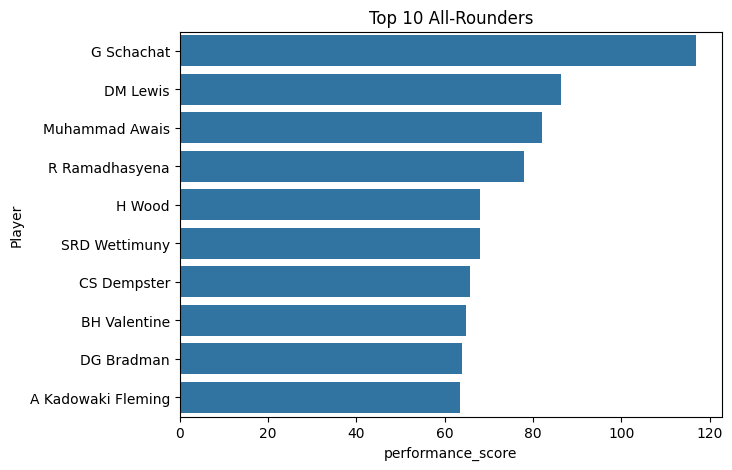

In [13]:
top10 = df.sort_values(
    by="performance_score",
    ascending=False
).head(10)

plt.figure(figsize=(7,5))
sns.barplot(
    x="performance_score",
    y="Player",
    data=top10
)
plt.title("Top 10 All-Rounders")
plt.show()

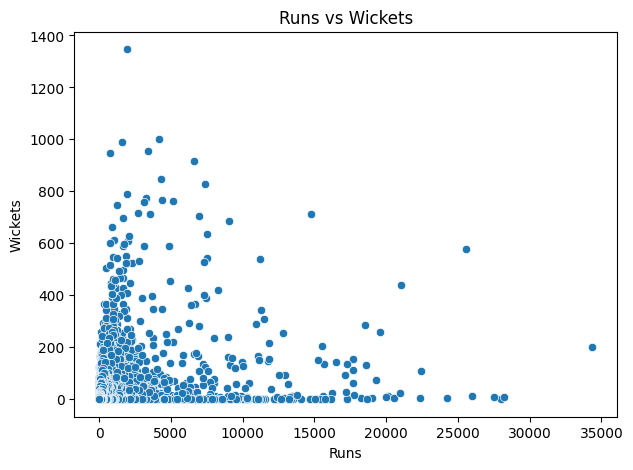

In [14]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="Runs",
    y="Wickets",
    data=df
)
plt.title("Runs vs Wickets")
plt.show()

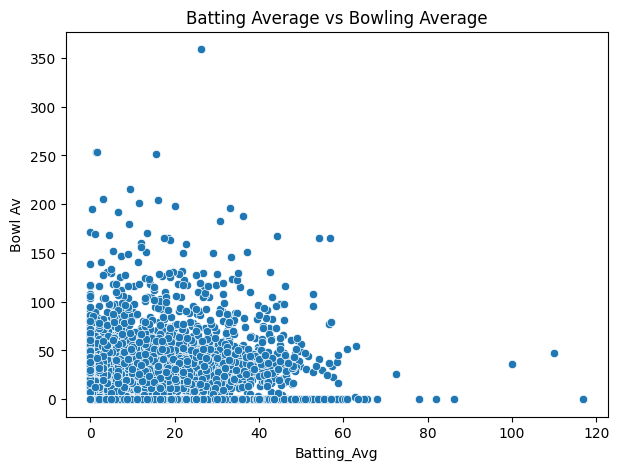

In [16]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="Batting_Avg",
    y="Bowl Av",
    data=df
)
plt.title("Batting Average vs Bowling Average")
plt.show()

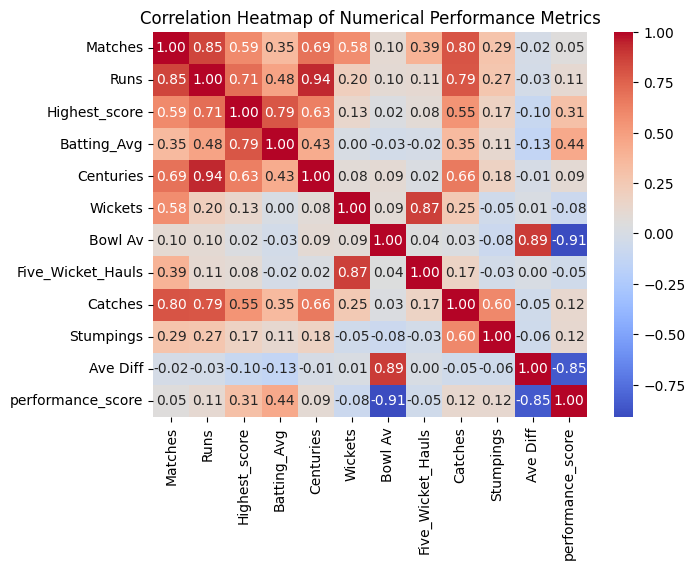

In [18]:
plt.figure(figsize=(7,5))
plt.title("Correlation Heatmap of Numerical Performance Metrics")
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.show()

Runs show a very high correlation with centuries (0.94), indicating that high run scorers frequently achieve centuries. Wickets also strongly correlate with five-wicket hauls (0.87), highlighting dominant bowlers. The performance score shows a strong negative correlation with bowling average (-0.91), confirming that players with lower bowling averages contribute significantly to overall all-rounder performance.

## Task 4 : Model Building & Evaluation

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
df.columns

Index(['Player', 'Span', 'Matches', 'Runs', 'Highest_score', 'Batting_Avg',
       'Centuries', 'Wickets', 'Bowl Av', 'Five_Wicket_Hauls', 'Catches',
       'Stumpings', 'Ave Diff', 'performance_score'],
      dtype='object')

In [21]:
df["fielding"] = df["Catches"] + df["Stumpings"]
features = ["Matches","Runs","Batting_Avg","Centuries","Wickets","Bowl Av","Five_Wicket_Hauls","fielding"]
X = df[features]
y = df["performance_score"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [31]:
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R2: 0.9905720522362089
RMSE: 2.7985736736577365


* The Random Forest regression model achieved an R² score of 0.99, indicating that the model explains approximately 99% of the variability in player performance scores, demonstrating excellent predictive capability.
* The model produced an RMSE value of 2.79, indicating that the predicted performance scores deviate from actual scores by an average of approximately 2.8 units, which suggests high prediction accuracy.

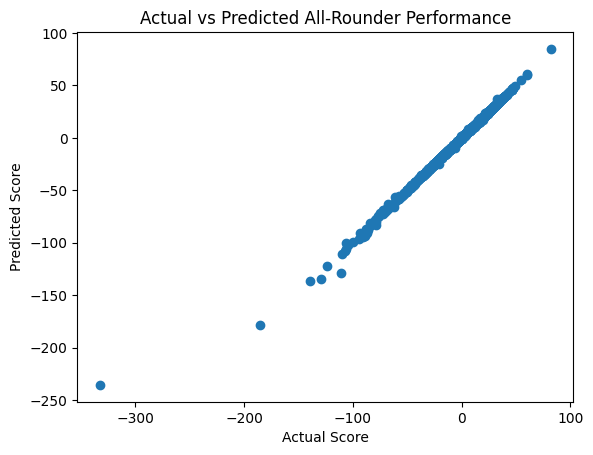

In [33]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted All-Rounder Performance")
plt.show()

In [34]:
print("Training Score:", rf.score(X_train, y_train))
print("Testing Score:", rf.score(X_test, y_test))

Training Score: 0.9996072616782754
Testing Score: 0.9905720522362089


* The model is not overfitted as Training score and Testings score difference is minimum

The model suggests that player performance can be predicted reliably using statistical indicators such as batting average, bowling average and Highest score.

Random Forest works well because:
* It captures non-linear relationships
* Handles feature interactions
* Works well with sports performance data